In [3]:
import h5py
import numpy as np
CRYSTAL = h5py.File('EELS_3D-out/EELS_3D_CRYSTAL_PML_a36-r245-ex_Dflx2.h5')
EMPTY = h5py.File('EELS_3D-out/EELS_3D_EMPTY_PML_a36-ex_flx2.h5')

In [4]:
q_e = 1.60217646e-19

In [5]:
Esim_crystal    = CRYSTAL['ex']     # NOT normalized E field in MEEP units
FLUXsim_crystal = CRYSTAL['flux']   # Electric field flux in MEEP units
Esim_empty      = EMPTY['ex']       # NOT normalized E field in MEEP units
FLUXsim_empty   = EMPTY['flux']     # Electric field flux in MEEP units

In [6]:
crystal = Esim_crystal[()]
empty   = Esim_empty[()]

In [28]:
FLUXsim_crystal[0]

np.float64(0.0)

In [7]:
# Normalization factor alpha
alpha_crystal = -q_e/FLUXsim_crystal[1:]
alpha_empty   = -q_e/FLUXsim_empty[1:]

crystal = alpha_crystal*Esim_crystal[:,1:]    # Electric field for 1 electron in MEEP units
empty   = alpha_empty*Esim_empty[:,1:]        # Electric field for 1 electron in MEEP units

In [8]:
crystal

array([[ 3.01510940e-18,  7.97099846e-19, -1.09639365e-18, ...,
        -2.67235169e-18, -4.65841625e-18, -4.68249324e-17],
       [ 2.54413944e-17,  1.89752325e-17,  1.20418580e-17, ...,
        -4.19505724e-18, -7.39002664e-18, -7.51212406e-17],
       [-0.00000000e+00,  2.50009132e-18,  4.66344037e-18, ...,
         3.87033930e-18,  6.77216848e-18,  6.86622856e-17],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         6.44849035e-18,  1.25260552e-17,  1.21605741e-16],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -4.75752802e-18, -1.20967492e-18,  7.46576749e-17],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -4.62407736e-18, -1.11199674e-17, -1.40608831e-16]],
      shape=(866, 3150))

In [9]:
empty

array([[ 3.01496832e-18,  7.97041476e-19, -1.09629233e-18, ...,
        -2.12830566e-18, -2.50104404e-18, -3.15532315e-18],
       [ 2.54402039e-17,  1.89738430e-17,  1.20407452e-17, ...,
        -1.33620175e-18, -1.57096736e-18, -1.98294147e-18],
       [-0.00000000e+00,  2.49990824e-18,  4.66300941e-18, ...,
         1.45514021e-18,  1.71035612e-18,  2.15830230e-18],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         2.22653106e-18,  2.91175869e-18,  3.52276106e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -1.75594183e-18, -3.79085432e-19,  2.05869765e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -1.78727179e-18, -2.78754719e-18, -4.31647049e-18]],
      shape=(866, 3150))

In [10]:
diff = crystal - empty  # Eind in MEEP units
diff

array([[ 1.41083598e-22,  5.83695918e-23, -1.01319260e-22, ...,
        -5.44046027e-19, -2.15737221e-18, -4.36696093e-17],
       [ 1.19045878e-21,  1.38950795e-21,  1.11280482e-21, ...,
        -2.85885549e-18, -5.81905928e-18, -7.31382991e-17],
       [ 0.00000000e+00,  1.83075320e-22,  4.30955000e-22, ...,
         2.41519909e-18,  5.06181236e-18,  6.65039833e-17],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         4.22195929e-18,  9.61429655e-18,  1.18082980e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.00158619e-18, -8.30589487e-19,  7.25989772e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.83680556e-18, -8.33242021e-18, -1.36292361e-16]],
      shape=(866, 3150))

In [11]:
with h5py.File("crystal_PML_a36-r245-ex_flx.hdf5", "w") as f:
    dset = f.create_dataset("ex", empty.shape, dtype='<f8', data=crystal)

In [12]:
with h5py.File("empty_PML_a36-ex_flx.hdf5", "w") as f:
    dset = f.create_dataset("ex", crystal.shape, dtype='<f8', data=empty)

In [13]:
with h5py.File("diff_PML_a36-r245-ex_flx.hdf5", "w") as f:
    dset = f.create_dataset("ex", diff.shape, dtype='<f8', data=diff)

# Check how the flux changes over time

In [14]:
import matplotlib.pyplot as plt

In [15]:
t = np.arange(0,len(FLUXsim_crystal))

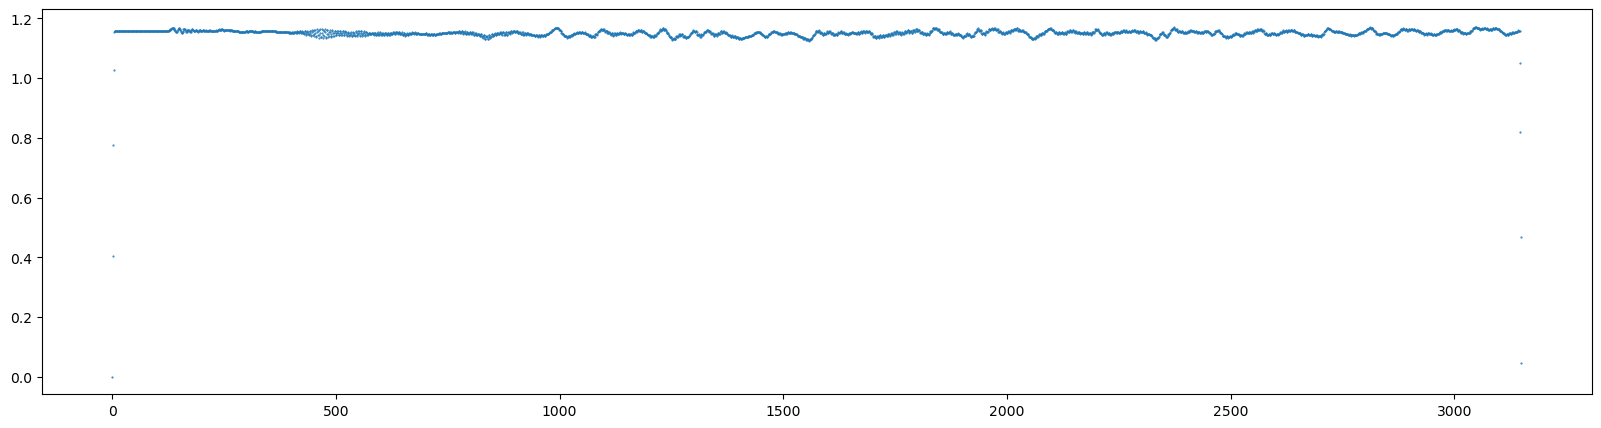

In [33]:
plt.figure(figsize=(20,5))
# plt.plot(t, FLUXsim_empty[()]/FLUXsim_empty[0]*100, '.', ms=1)
plt.plot(t[:], FLUXsim_crystal[:], '.', ms=1)

In [17]:
FLUXsim_crystal[()]

array([0.        , 0.4055247 , 0.7773679 , ..., 0.82080187, 0.46762418,
       0.04633879], shape=(3151,))